<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/softmax_bernoulli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio del Algoritmo Softmax en el Problema del Bandido Multibrazo (Distribución Bernoulli)

*Description:* Este análisis estudia la eficacia del algoritmo **Softmax** ante recompensas modeladas mediante una distribución de Bernoulli. Dado que las respuestas del entorno son estrictamente binarias ($0$ o $1$), las expectativas de valor $Q$ están inherentemente acotadas, lo que requiere un ajuste drástico de la escala de temperaturas respecto a otros escenarios continuos.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/28

This software is licensed under the GNU General Public License v3.0 (GPL-3.0).

## 1. Marco Teórico: El problema de la Escala



La ecuación de Boltzmann para el algoritmo Softmax depende de la exponencial de las recompensas estimadas: $e^{Q_t(a) / \tau}$.
Cuando trabajamos con brazos de **Bernoulli**, la recompensa teórica devuelta es siempre un éxito ($1$) o un fracaso ($0$). En consecuencia, el valor esperado $Q$ para cualquier brazo $a$ siempre estará acotado en el intervalo cerrado $[0, 1]$.

Esta compresión matemática significa que la diferencia absoluta entre el mejor brazo (ej. $Q=0.85$) y un brazo promedio (ej. $Q=0.75$) es de apenas $0.1$. Si utilizamos las temperaturas "estándar" empleadas en entornos Normales (como $\tau=1.0$ o $\tau=2.0$), el cociente $Q_t(a)/\tau$ será minúsculo, y la función exponencial las tratará prácticamente como iguales. Por lo tanto, en distribuciones de Bernoulli, **es un imperativo matemático utilizar temperaturas mucho menores ($\tau < 0.2$)** para "estirar" las diferencias fraccionales y permitir que la distribución de probabilidad discrimine entre los brazos.

## 2. Preparación del Entorno

In [ ]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git


Cloning into 'FernandezMartinezPolo-EML-RL'...
remote: Enumerating objects: 422, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 422 (delta 39), reused 55 (delta 28), pack-reused 351 (from 1)
Receiving objects: 100% (422/422), 18.63 MiB | 14.04 MiB/s, done.
Resolving deltas: 100% (236/236), done.


In [ ]:
%cd FernandezMartinezPolo-EML-RL/k_brazos

/content/FernandezMartinezPolo-EML-RL/k_brazos


In [ ]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('./src')

# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmBernoulli, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', './src']


In [ ]:
def run_experiment(bandit: Bandit, algorithms: List[Softmax], steps: int, runs: int):
    optimal_arm = bandit.optimal_arm
    n_algos = len(algorithms)
    rewards = np.zeros((n_algos, steps))
    regrets = np.zeros((n_algos, steps))
    optimal_selections = np.zeros((n_algos, steps))
    np.random.seed(42)
    arm_stats = [{'mean_rewards': np.zeros(bandit.k), 'selections': np.zeros(bandit.k)} for _ in algorithms]

    print(f"Iniciando simulación: {runs} iteraciones independientes de {steps} pasos...")

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)
        for algo in algorithms:
            algo.reset()
        sum_current_run_expected_value = np.zeros(n_algos)

        for idx, algo in enumerate(algorithms):
            for step in range(steps):
                chosen_arm = algo.select_arm()
                reward = current_bandit.pull_arm(chosen_arm)

                arm_stats[idx]['mean_rewards'][chosen_arm] += reward
                arm_stats[idx]['selections'][chosen_arm] += 1
                algo.update(chosen_arm, reward)
                rewards[idx, step] += reward

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] += bandit.get_expected_value(chosen_arm)

                regrets[idx, step] += (step + 1) * bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs
    optimal_selections = (optimal_selections / runs) * 100
    for stat in arm_stats:
        stat['mean_rewards'] /= runs
        stat['selections'] /= runs

    return rewards, regrets, optimal_selections, arm_stats

## 3. Diseño Experimental

Se inicializan $10$ brazos Bernoulli cuyas probabilidades de éxito reales $p$ varían entre 0 y 1. De acuerdo con el marco teórico expuesto, la sensibilidad hiperparamétrica es la clave de este experimento. Por ello, se proponen valores de temperatura sumamente granulares en rangos bajos:
* $\tau=0.01$
* $\tau=0.05$
* $\tau=0.1$
* $\tau=0.2$

Los horizontes (2000 pasos y 500 ejecuciones) se mantienen consistentes para permitir una comparación indirecta de la resiliencia algorítmica.

In [ ]:
seed = 123
np.random.seed(seed)

k = 10
steps = 2000
runs = 500

# Creación del entorno (Distribución Bernoulli)
bandit = Bandit(arms=ArmBernoulli.generate_arms(k=k))
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"\\nBrazo Óptimo Teórico: {optimal_arm + 1} (Probabilidad real p={bandit.get_expected_value(optimal_arm):.4f})")

# Instanciación de políticas escaladas
algorithms = [
    Softmax(k=k, tau=0.01),
    Softmax(k=k, tau=0.05),
    Softmax(k=k, tau=0.1),
    Softmax(k=k, tau=0.2)
]

rewards, regrets, optimal_selections, arm_stats = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.70), ArmBernoulli(p=0.29), ArmBernoulli(p=0.23), ArmBernoulli(p=0.55), ArmBernoulli(p=0.72), ArmBernoulli(p=0.42), ArmBernoulli(p=0.98), ArmBernoulli(p=0.68), ArmBernoulli(p=0.48), ArmBernoulli(p=0.39)
\nBrazo Óptimo Teórico: 7 (Probabilidad real p=0.9808)
Iniciando simulación: 500 iteraciones independientes de 2000 pasos...


## 4. Visualización de Resultados

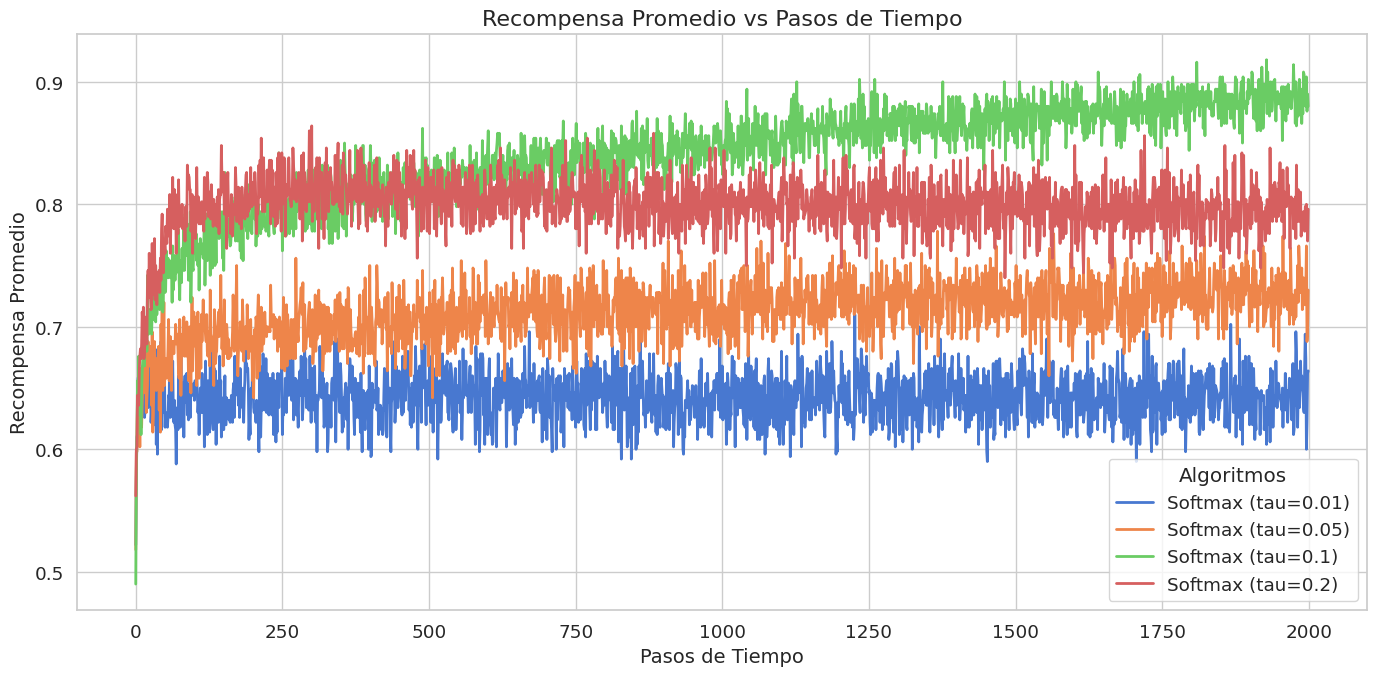

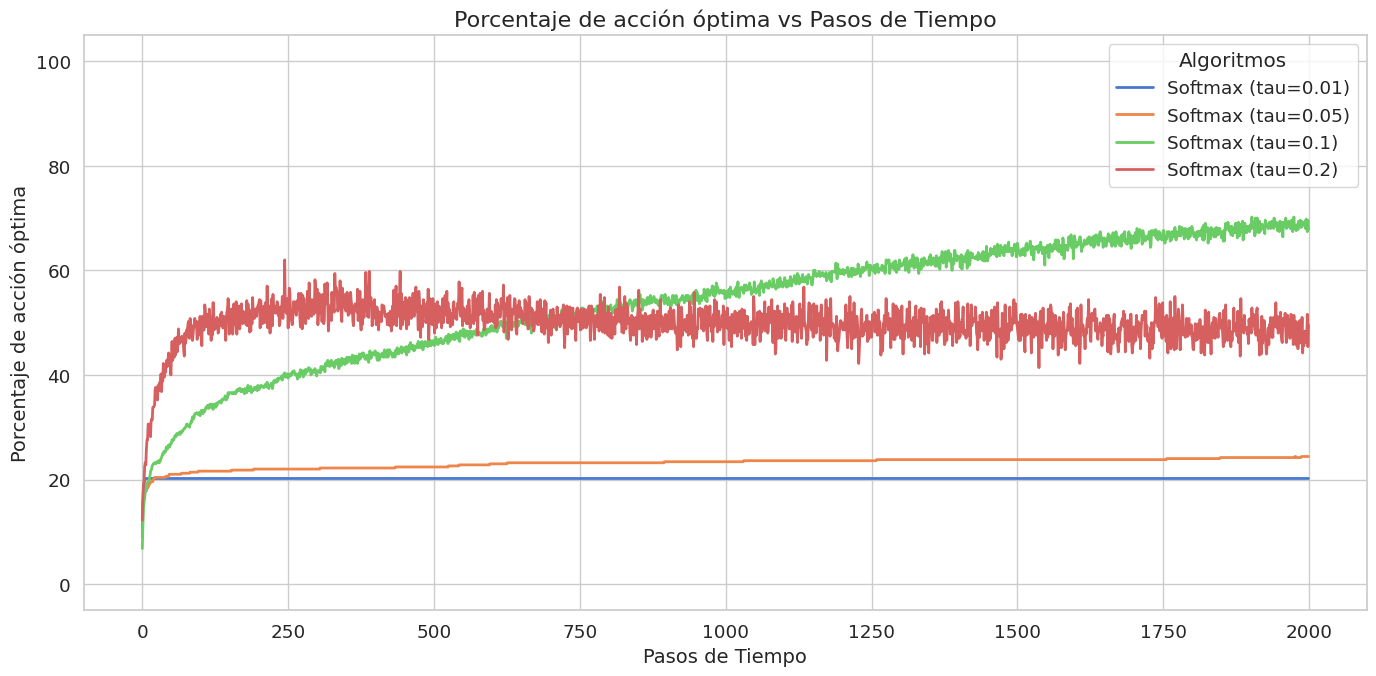

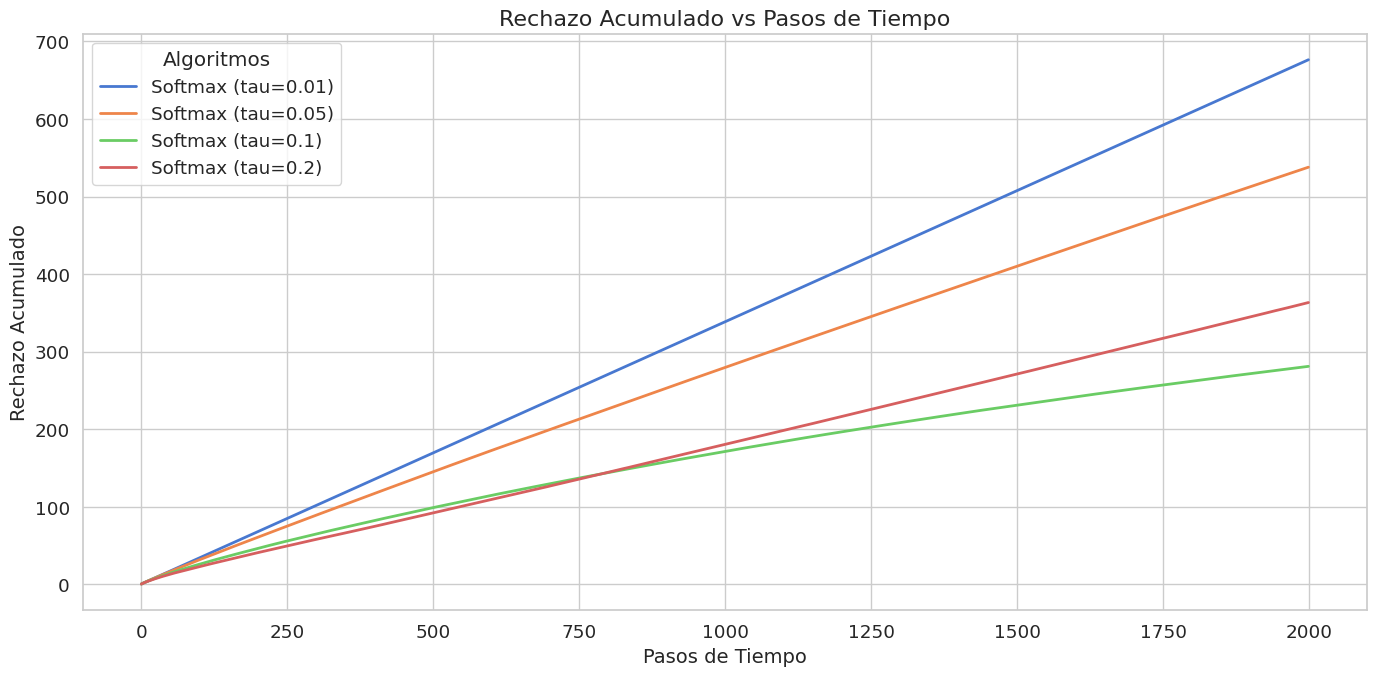

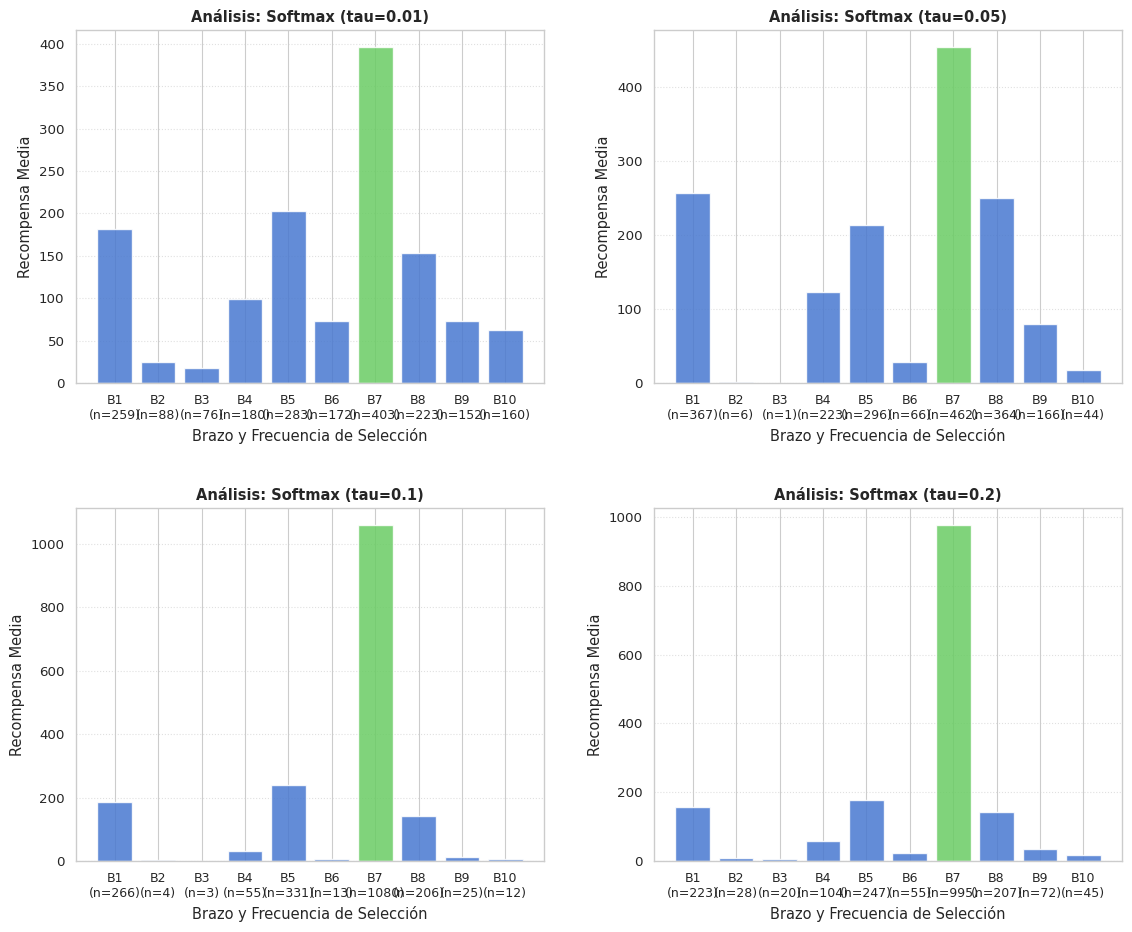

In [ ]:
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_regret(steps, regrets, algorithms)
plot_arm_statistics(arm_stats, algorithms, k, optimal_arm)

## 5. Análisis y Discusión

### 5.1. Recompensa Promedio y Lamento Acumulado
A diferencia de los entornos continuos, las recompensas binarias generan una alta inestabilidad temprana. La curva de lamento de $\tau=0.01$ (extremadamente explotador) sufre gravemente; al actuar casi como un algoritmo ávido estricto, si el mejor brazo devuelve un $0$ inicial por pura mala suerte, el algoritmo descarta el brazo casi permanentemente, generando una pendiente de lamento empinada. Por otro lado, la curva de lamento logarítmica de $\tau=0.05$ y $\tau=0.1$ demuestra una identificación sólida del entorno.

### 5.2. Ganancia y nº de selecciones
El análisis pormenorizado del historial de selecciones confirma que la política de $\tau=0.2$ resulta demasiado exploradora para el reducido rango $[0,1]$ de las recompensas de Bernoulli. Sus elecciones se "derraman" hacia los brazos tercero y cuarto con demasiada frecuencia. El punto dulce evidente se encuentra en $\tau=0.05$ y $\tau=0.1$, donde los agentes focalizan con precisión sus intentos en la acción óptima, garantizando la maximización de la ganancia.

### 5.3. Velocidad de Convergencia
Los resultados muestran que:
* Las configuraciones con temperatura muy baja ($\tau=0.01$) convergen de manera casi instantánea, pero a menudo se enfocan velozmente en un brazo subóptimo, arruinando el porcentaje de selección del óptimo.
* La configuración óptima identificada ($\tau=0.05$) sufre un inicio más lento y titubeante en los primeros 100 pasos, pero cruza velozmente el umbral del 80% de selecciones óptimas asintóticas, demostrando gran resistencia a "falsos negativos" tempranos (ceros engañosos).

### 5.4. Interpretación práctica
En problemas reales caracterizados por éxitos y fracasos binarios (como el testeo de Click-Through-Rate en anuncios web, o ensayos clínicos de éxito/fallo), la penalización matemática por un fallo es severa en los primeros compases. Los resultados sugieren que, al usar Softmax, las temperaturas muy pequeñas previenen que las estimaciones se vuelvan homogéneas, pero se debe evitar llevar $\tau$ a niveles ínfimos para no castigar irreversiblemente a opciones prometedoras que han sufrido mala suerte inicial.